# 0. les biblios

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Charger monitoring_device_operations.csv

In [2]:
# Charger les données
df = pd.read_csv("monitoring_device_operations.csv")

In [3]:
# 1. Dimensions et types de colonnes
print("Dimensions :", df.shape)
print("\nTypes de colonnes :")
df.info()

Dimensions : (4994, 11)

Types de colonnes :
<class 'pandas.DataFrame'>
RangeIndex: 4994 entries, 0 to 4993
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   device_operation_id   4994 non-null   str    
 1   site_code             4994 non-null   str    
 2   device_reference      4994 non-null   str    
 3   operation_start       4994 non-null   str    
 4   operation_end         4994 non-null   str    
 5   uptime_pct            4994 non-null   str    
 6   acoustic_quality      4994 non-null   float64
 7   maintenance_type      4994 non-null   str    
 8   fault_code            189 non-null    str    
 9   maintenance_provider  4964 non-null   str    
 10  record_status         4994 non-null   str    
dtypes: float64(1), str(10)
memory usage: 429.3 KB


In [4]:
# 2. Échantillon des données
print("\nPremières lignes :")
display(df.head())


Premières lignes :


,device_operation_id,site_code,device_reference,operation_start,operation_end,uptime_pct,acoustic_quality,maintenance_type,fault_code,maintenance_provider,record_status
0,DOP-0000001,KNT-KES,DEV-KNTKES-2,2019-01-01T00:00:00,2019-01-31T23:59:59,92.3,85.9,routine inspection,NaN,ECO-SERVICE-2,closed
1,DOP-0000002,KNT-KES,DEV-KNTKES-2,2019-02-01T00:00:00,2019-02-28T23:59:59,80.6,79.6,routine inspection,NaN,ECO-SERVICE-2,closed
2,DOP-0000003,KNT-KES,DEV-KNTKES-2,2019-03-01T00:00:00,2019-03-31T23:59:59,94.9,82.5,routine inspection,NaN,ECO-SERVICE-2,closed
3,DOP-0000004,KNT-KES,DEV-KNTKES-2,2019-04-01T00:00:00,2019-04-30T23:59:59,94.8,84.8,routine inspection,NaN,ECO-SERVICE-2,closed
4,DOP-0000005,KNT-KES,DEV-KNTKES-2,2019-05-01T00:00:00,2019-05-31T23:59:59,87.7,69.2,routine inspection,NaN,ECO-SERVICE-2,closed


- 4994 lignes et 11 colonnes.
- Une ligne = une opération mensuelle d'un appareil de monitoring sur un site (`site_code` + `device_reference` + `operation_start`).
- Toutes les colonnes sont en `object`, y compris les mesures et les dates : même signal qu'avant, des formats sont mélangés.

# 2. Doublons

### a- Doublons de lignes

In [5]:
print("Nombre de lignes strictement dupliquées :", df.duplicated().sum())
display(df[df.duplicated(keep=False)].sort_values('device_operation_id'))

Nombre de lignes strictement dupliquées : 2


,device_operation_id,site_code,device_reference,operation_start,operation_end,uptime_pct,acoustic_quality,maintenance_type,fault_code,maintenance_provider,record_status
1225,DOP-0001226,KNT-CHP,DEV-KNTCHP-3,2023-08-01T00:00:00,2023-08-31T23:59:59,93.2,73.5,routine inspection,NaN,ECO-SERVICE-1,closed
4993,DOP-0001226,KNT-CHP,DEV-KNTCHP-3,2023-08-01T00:00:00,2023-08-31T23:59:59,93.2,73.5,routine inspection,NaN,ECO-SERVICE-1,closed
1390,DOP-0001391,KNT-WUQ,DEV-KNTWUQ-2,2024-05-01T00:00:00,2024-05-31T23:59:59,92.7,78.6,routine inspection,NaN,ECO-SERVICE-3,closed
4992,DOP-0001391,KNT-WUQ,DEV-KNTWUQ-2,2024-05-01T00:00:00,2024-05-31T23:59:59,92.7,78.6,routine inspection,NaN,ECO-SERVICE-3,closed


### b- Doublons sur l'identifiant métier

`device_operation_id` devrait être un identifiant unique par opération.

In [6]:
print("device_operation_id dupliqués :", df['device_operation_id'].duplicated().sum())
display(df[df['device_operation_id'].duplicated(keep=False)].sort_values('device_operation_id'))

# Vérification croisée avec la clé (site, appareil, début d'opération)
cle = ['site_code', 'device_reference', 'operation_start']
print("Couples (site, appareil, début) dupliqués :", df.duplicated(subset=cle).sum())

device_operation_id dupliqués : 2


,device_operation_id,site_code,device_reference,operation_start,operation_end,uptime_pct,acoustic_quality,maintenance_type,fault_code,maintenance_provider,record_status
1225,DOP-0001226,KNT-CHP,DEV-KNTCHP-3,2023-08-01T00:00:00,2023-08-31T23:59:59,93.2,73.5,routine inspection,NaN,ECO-SERVICE-1,closed
4993,DOP-0001226,KNT-CHP,DEV-KNTCHP-3,2023-08-01T00:00:00,2023-08-31T23:59:59,93.2,73.5,routine inspection,NaN,ECO-SERVICE-1,closed
1390,DOP-0001391,KNT-WUQ,DEV-KNTWUQ-2,2024-05-01T00:00:00,2024-05-31T23:59:59,92.7,78.6,routine inspection,NaN,ECO-SERVICE-3,closed
4992,DOP-0001391,KNT-WUQ,DEV-KNTWUQ-2,2024-05-01T00:00:00,2024-05-31T23:59:59,92.7,78.6,routine inspection,NaN,ECO-SERVICE-3,closed


Couples (site, appareil, début) dupliqués : 2


- Solution

In [7]:
# On supprime les doublons stricts puis les doublons d'identifiant (on garde la 1ère occurrence)
df = df.drop_duplicates(keep='first')
df = df.drop_duplicates(subset='device_operation_id', keep='first')

# Vérification
print("Nombre de lignes après suppression :", df.shape[0])
print("Doublons stricts restants :", df.duplicated().sum())
print("Doublons d'identifiant restants :", df['device_operation_id'].duplicated().sum())

Nombre de lignes après suppression : 4992
Doublons stricts restants : 0
Doublons d'identifiant restants : 0


### c- Doublons de colonnes

In [8]:
noms_doublons = df.columns[df.columns.duplicated()]
print("Noms de colonnes en double :", noms_doublons.tolist())

contenu_doublons = df.columns[df.T.duplicated()]
print("Colonnes avec un contenu dupliqué :", contenu_doublons.tolist())

Noms de colonnes en double : []
Colonnes avec un contenu dupliqué : []


In [9]:
# site_code et device_reference se correspondent-ils parfaitement ?
print("Appareils par site :", df.groupby('site_code')['device_reference'].nunique().value_counts())
print("Sites par appareil :", df.groupby('device_reference')['site_code'].nunique().value_counts())

Appareils par site : device_reference
1    64
Name: count, dtype: int64
Sites par appareil : site_code
1    64
Name: count, dtype: int64


→ Correspondance 1-pour-1 entre `site_code` et `device_reference` : chaque site n'a qu'un seul appareil dans
ce jeu de données. On garde les deux colonnes : l'une identifie le lieu, l'autre le matériel — utile pour la
traçabilité si un appareil est un jour remplacé sur le même site.

# 3. Formats incohérents

### Les types de chaque colonne :

In [10]:
print(df.dtypes)

device_operation_id         str
site_code                   str
device_reference            str
operation_start             str
operation_end               str
uptime_pct                  str
acoustic_quality        float64
maintenance_type            str
fault_code                  str
maintenance_provider        str
record_status               str
dtype: object


### - Vérifier le format de device_operation_id et device_reference

In [11]:
print("Format device_operation_id :", df['device_operation_id'].str.replace(r'\d', '9', regex=True).unique())
print("Format device_reference :", df['device_reference'].str.replace(r'[A-Z0-9]', 'X', regex=True).unique())
print("Manquants :", df['device_operation_id'].isna().sum(), df['device_reference'].isna().sum())

Format device_operation_id : <StringArray>
['DOP-9999999']
Length: 1, dtype: str
Format device_reference : <StringArray>
['XXX-XXXXXX-X']
Length: 1, dtype: str
Manquants : 0 0


→ Formats homogènes (`DOP-XXXXXXX` et `DEV-XXXXXX-X`). Rien à corriger.

### - Vérifier le format de operation_start / operation_end (dates) <--->

In [12]:
start_dt = pd.to_datetime(df['operation_start'], errors='coerce')
end_dt = pd.to_datetime(df['operation_end'], errors='coerce')

print("operation_start non convertibles :", start_dt.isna().sum() - df['operation_start'].isna().sum())
print("operation_end non convertibles :", end_dt.isna().sum() - df['operation_end'].isna().sum())

# Exemples de formats qui posent problème
mask_bad = end_dt.isna() & df['operation_end'].notna()
print("\nExemples de operation_end non convertibles :")
display(df.loc[mask_bad, ['device_operation_id', 'operation_start', 'operation_end']].head(10))

operation_start non convertibles : 0
operation_end non convertibles : 20

Exemples de operation_end non convertibles :


,device_operation_id,operation_start,operation_end
232,DOP-0000233,2025-05-01T00:00:00,31-May-2025 23:59:59
267,DOP-0000268,2021-10-01T00:00:00,31-Oct-2021 23:59:59
614,DOP-0000615,2024-09-01T00:00:00,30-Sep-2024 23:59:59
670,DOP-0000671,2022-11-01T00:00:00,2022/11/30 23:59:59
921,DOP-0000922,2024-04-01T00:00:00,30-Apr-2024 23:59:59
939,DOP-0000940,2019-04-01T00:00:00,2019/04/30 23:59:59
1017,DOP-0001018,2019-04-01T00:00:00,30/04/2019 23:59:59
1137,DOP-0001138,2022-10-01T00:00:00,2022/10/31 23:59:59
1204,DOP-0001205,2021-11-01T00:00:00,30-Nov-2021 23:59:59
1324,DOP-0001325,2025-05-01T00:00:00,31/05/2025 23:59:59


**Constat :** `operation_start` est toujours au format ISO, mais `operation_end` mélange plusieurs formats :
`31-May-2025 23:59:59`, `2022/11/30 23:59:59`, `30/04/2019 23:59:59`. C'est exactement le cas "format
variable" décrit dans le cours.

- Solution

In [13]:
# operation_start est toujours au format ISO : on le précise pour éviter que le mode "mixed"
# ne le confonde avec un format day-first (piège classique : 2019-02-01 lu comme le 2 janvier)
df['operation_start'] = pd.to_datetime(df['operation_start'], format='ISO8601', errors='coerce')

# operation_end mélange plusieurs formats (dont certains ambigus type JJ/MM/AAAA) : on laisse
# pandas déduire le format ligne par ligne, avec dayfirst pour lever l'ambiguïté JJ/MM vs MM/JJ
df['operation_end'] = pd.to_datetime(df['operation_end'], format='mixed', errors='coerce', dayfirst=True)

# Vérification
print("operation_start non convertibles :", df['operation_start'].isna().sum())
print("operation_end non convertibles :", df['operation_end'].isna().sum())
print("Lignes où end <= start :", (df['operation_end'] <= df['operation_start']).sum())
print("Types :", df['operation_start'].dtype, df['operation_end'].dtype)

operation_start non convertibles : 0
operation_end non convertibles : 0
Lignes où end <= start : 0
Types : datetime64[us] datetime64[us]


### - Vérifier le format de uptime_pct et acoustic_quality (numériques) <--->

In [14]:
for col in ['uptime_pct', 'acoustic_quality']:
    s = df[col]
    non_num = s[pd.to_numeric(s, errors='coerce').isna() & s.notna()]
    print(col, "| non convertibles :", len(non_num), "| exemples :", non_num.unique()[:8])

uptime_pct | non convertibles : 50 | exemples : <StringArray>
['99,3', '91,3', '98,1', '90,9', '100,0', '92,9', '92,0', '96,3']
Length: 8, dtype: str
acoustic_quality | non convertibles : 0 | exemples : []


**Constat :** `uptime_pct` a le même problème de virgule décimale que dans `environmental_monthly.csv`.

- Solution

In [15]:
df['uptime_pct'] = df['uptime_pct'].astype(str).str.replace(',', '.', regex=False)
df['uptime_pct'] = pd.to_numeric(df['uptime_pct'], errors='coerce')
df['acoustic_quality'] = pd.to_numeric(df['acoustic_quality'], errors='coerce')

# Vérification
print(df[['uptime_pct', 'acoustic_quality']].dtypes)
print(df[['uptime_pct', 'acoustic_quality']].isna().sum())

uptime_pct          float64
acoustic_quality    float64
dtype: object
uptime_pct          0
acoustic_quality    0
dtype: int64


### - Vérifier le format de maintenance_type (catégorielle) <--->

In [16]:
print(df['maintenance_type'].value_counts(dropna=False))

maintenance_type
routine inspection        4783
corrective maintenance     137
sensor replacement          52
ROUTINE INSPECTION          12
Routine Inspection           8
Name: count, dtype: int64


**Constat :** 5 valeurs pour 3 catégories réelles (`routine inspection` / `ROUTINE INSPECTION` /
`Routine Inspection`). Même correction que pour `land_use_category` dans le fichier écologique.

- Solution

In [17]:
df['maintenance_type'] = df['maintenance_type'].str.strip().str.lower()

# Vérification
print(df['maintenance_type'].value_counts())

maintenance_type
routine inspection        4803
corrective maintenance     137
sensor replacement          52
Name: count, dtype: int64


### - Vérifier le format de record_status (catégorielle)

In [18]:
print(df['record_status'].value_counts(dropna=False))

record_status
closed    4972
CLOSED      13
Closed       7
Name: count, dtype: int64


- Solution

In [19]:
df['record_status'] = df['record_status'].str.strip().str.lower()
print(df['record_status'].value_counts())

record_status
closed    4992
Name: count, dtype: int64


→ Une seule vraie modalité (`closed`) : cette colonne n'apporte aucune information (variance nulle),
elle sera écartée des analyses de corrélation/visualisation mais conservée dans le fichier exporté.

### - Vérifier le format de maintenance_provider (catégorielle)

In [20]:
print(df['maintenance_provider'].value_counts(dropna=False))
print("Manquants :", df['maintenance_provider'].isna().sum())

maintenance_provider
ECO-SERVICE-2    1242
ECO-SERVICE-1    1241
ECO-SERVICE-4    1240
ECO-SERVICE-3    1239
NaN                30
Name: count, dtype: int64
Manquants : 30


# 4. Valeurs manquantes

### a. Constat du problème

In [21]:
print("Valeurs manquantes par colonne :")
print(df.isna().sum())

print("\nPourcentage de manquants par colonne :")
print((df.isna().sum() / len(df) * 100).round(2))

Valeurs manquantes par colonne :
device_operation_id        0
site_code                  0
device_reference           0
operation_start            0
operation_end              0
uptime_pct                 0
acoustic_quality           0
maintenance_type           0
fault_code              4803
maintenance_provider      30
record_status              0
dtype: int64

Pourcentage de manquants par colonne :
device_operation_id      0.00
site_code                0.00
device_reference         0.00
operation_start          0.00
operation_end            0.00
uptime_pct               0.00
acoustic_quality         0.00
maintenance_type         0.00
fault_code              96.21
maintenance_provider     0.60
record_status            0.00
dtype: float64


- `fault_code` : ~96% de manquants
- `maintenance_provider` : 30 manquants (0.6%)

Deux logiques différentes, comme pour `environmental_monthly.csv`.

### b. fault_code : l'absence de code EST une information

Hypothèse : un code de panne n'est renseigné que lors d'une intervention corrective, pas lors d'une
inspection de routine.

In [22]:
print(pd.crosstab(df['maintenance_type'], df['fault_code'], dropna=False))

fault_code              MICROPHONE_DRIFT  POWER_INTERRUPTION  STORAGE_LIMIT  \
maintenance_type                                                              
corrective maintenance                45                  36             56   
routine inspection                     0                   0              0   
sensor replacement                    52                   0              0   

fault_code               NaN  
maintenance_type              
corrective maintenance     0  
routine inspection      4803  
sensor replacement         0  


→ Preuve par les données : `fault_code` est rempli à 100% pour `corrective maintenance` et
`sensor replacement`, et jamais pour `routine inspection`. Le vide correspond donc à « aucune panne » et
non à une perte d'information.

In [23]:
df['fault_code'] = df['fault_code'].fillna('NO_FAULT')

# Vérification
print(df['fault_code'].value_counts())
print("Manquants restants :", df['fault_code'].isna().sum())

fault_code
NO_FAULT              4803
MICROPHONE_DRIFT        97
STORAGE_LIMIT           56
POWER_INTERRUPTION      36
Name: count, dtype: int64
Manquants restants : 0


### c. maintenance_provider : inférence par appareil

Hypothèse : chaque site/appareil est toujours suivi par le même prestataire de maintenance.

In [24]:
trous = df[df['maintenance_provider'].isna()]
print("Lignes concernées :", len(trous), "sur", trous['site_code'].nunique(), "sites différents")

sites_a_verifier = trous['site_code'].unique()
for site in sites_a_verifier[:10]:
    prestataires_connus = df[(df['site_code'] == site) & (df['maintenance_provider'].notna())]['maintenance_provider'].unique()
    print(site, "->", prestataires_connus)

Lignes concernées : 30 sur 23 sites différents
KNT-GKR -> <StringArray>
['ECO-SERVICE-4']
Length: 1, dtype: str
KNT-JQG -> <StringArray>
['ECO-SERVICE-3']
Length: 1, dtype: str
KNT-YRG -> <StringArray>
['ECO-SERVICE-2']
Length: 1, dtype: str
KNT-WUQ -> <StringArray>
['ECO-SERVICE-3']
Length: 1, dtype: str
KNT-GGN -> <StringArray>
['ECO-SERVICE-1']
Length: 1, dtype: str
KNT-QWU -> <StringArray>
['ECO-SERVICE-2']
Length: 1, dtype: str
KNT-TLQ -> <StringArray>
['ECO-SERVICE-3']
Length: 1, dtype: str
KNT-VXR -> <StringArray>
['ECO-SERVICE-1']
Length: 1, dtype: str
AVL-TRP -> <StringArray>
['ECO-SERVICE-1']
Length: 1, dtype: str
AVL-HTY -> <StringArray>
['ECO-SERVICE-2']
Length: 1, dtype: str


→ Résultat : chaque site n'a qu'un seul prestataire dans tout le reste du dataset. Hypothèse confirmée.

- Solution

In [25]:
df['maintenance_provider'] = df.groupby('site_code')['maintenance_provider'].transform(
    lambda s: s.fillna(s.mode()[0]) if not s.mode().empty else s
)

# Vérification
print("Valeurs manquantes restantes :")
print(df.isna().sum())

Valeurs manquantes restantes :
device_operation_id     0
site_code               0
device_reference        0
operation_start         0
operation_end           0
uptime_pct              0
acoustic_quality        0
maintenance_type        0
fault_code              0
maintenance_provider    0
record_status           0
dtype: int64


# 5. Gestion des variables catégorielles

### a. Création de variables temporelles

In [26]:
df['year'] = df['operation_start'].dt.year
df['month'] = df['operation_start'].dt.month
df['duration_days'] = (df['operation_end'] - df['operation_start']).dt.days

display(df.head())

,device_operation_id,site_code,device_reference,operation_start,operation_end,uptime_pct,acoustic_quality,maintenance_type,fault_code,maintenance_provider,record_status,year,month,duration_days
0,DOP-0000001,KNT-KES,DEV-KNTKES-2,2019-01-01,2019-01-31 23:59:59,92.3,85.9,routine inspection,NO_FAULT,ECO-SERVICE-2,closed,2019,1,30
1,DOP-0000002,KNT-KES,DEV-KNTKES-2,2019-02-01,2019-02-28 23:59:59,80.6,79.6,routine inspection,NO_FAULT,ECO-SERVICE-2,closed,2019,2,27
2,DOP-0000003,KNT-KES,DEV-KNTKES-2,2019-03-01,2019-03-31 23:59:59,94.9,82.5,routine inspection,NO_FAULT,ECO-SERVICE-2,closed,2019,3,30
3,DOP-0000004,KNT-KES,DEV-KNTKES-2,2019-04-01,2019-04-30 23:59:59,94.8,84.8,routine inspection,NO_FAULT,ECO-SERVICE-2,closed,2019,4,29
4,DOP-0000005,KNT-KES,DEV-KNTKES-2,2019-05-01,2019-05-31 23:59:59,87.7,69.2,routine inspection,NO_FAULT,ECO-SERVICE-2,closed,2019,5,30


### b. Variables ordonnées

Aucune variable réellement ordinale : `maintenance_type`, `fault_code` et `maintenance_provider` sont des
catégories sans hiérarchie naturelle. `record_status` n'a qu'une seule modalité.

### c. Encodage des variables nominales (One-Hot)

On encode `maintenance_type` et `fault_code`. `maintenance_provider` (4 modalités) est également
encodable. `site_code` et `device_reference` restent des identifiants, non encodés (trop de modalités,
information déjà portée par ces colonnes en tant que clé).

In [27]:
df_stats = df.copy()

cols_nominales = ['maintenance_type', 'fault_code', 'maintenance_provider']
df_enc = pd.get_dummies(df, columns=cols_nominales, drop_first=False, dtype=int)

print("Nouvelles dimensions du dataset :", df_enc.shape)
display(df_enc.head())

Nouvelles dimensions du dataset : (4992, 22)


,device_operation_id,site_code,device_reference,operation_start,operation_end,uptime_pct,acoustic_quality,record_status,year,month,...,maintenance_type_routine inspection,maintenance_type_sensor replacement,fault_code_MICROPHONE_DRIFT,fault_code_NO_FAULT,fault_code_POWER_INTERRUPTION,fault_code_STORAGE_LIMIT,maintenance_provider_ECO-SERVICE-1,maintenance_provider_ECO-SERVICE-2,maintenance_provider_ECO-SERVICE-3,maintenance_provider_ECO-SERVICE-4
0,DOP-0000001,KNT-KES,DEV-KNTKES-2,2019-01-01,2019-01-31 23:59:59,92.3,85.9,closed,2019,1,...,1,0,0,1,0,0,0,1,0,0
1,DOP-0000002,KNT-KES,DEV-KNTKES-2,2019-02-01,2019-02-28 23:59:59,80.6,79.6,closed,2019,2,...,1,0,0,1,0,0,0,1,0,0
2,DOP-0000003,KNT-KES,DEV-KNTKES-2,2019-03-01,2019-03-31 23:59:59,94.9,82.5,closed,2019,3,...,1,0,0,1,0,0,0,1,0,0
3,DOP-0000004,KNT-KES,DEV-KNTKES-2,2019-04-01,2019-04-30 23:59:59,94.8,84.8,closed,2019,4,...,1,0,0,1,0,0,0,1,0,0
4,DOP-0000005,KNT-KES,DEV-KNTKES-2,2019-05-01,2019-05-31 23:59:59,87.7,69.2,closed,2019,5,...,1,0,0,1,0,0,0,1,0,0


# 6. Voir les outliers (colonnes numériques)

In [28]:
cols_num = ['uptime_pct', 'acoustic_quality', 'duration_days']
display(df_stats[cols_num].describe().T)

,count,mean,std,min,25%,50%,75%,max
uptime_pct,4992.0,92.525962,7.926554,23.1,90.2,93.8,97.300,100.0
acoustic_quality,4992.0,78.992448,8.506378,20.0,73.9,79.3,84.625,100.0
duration_days,4992.0,29.423077,0.824692,27.0,29.0,30.0,30.000,30.0


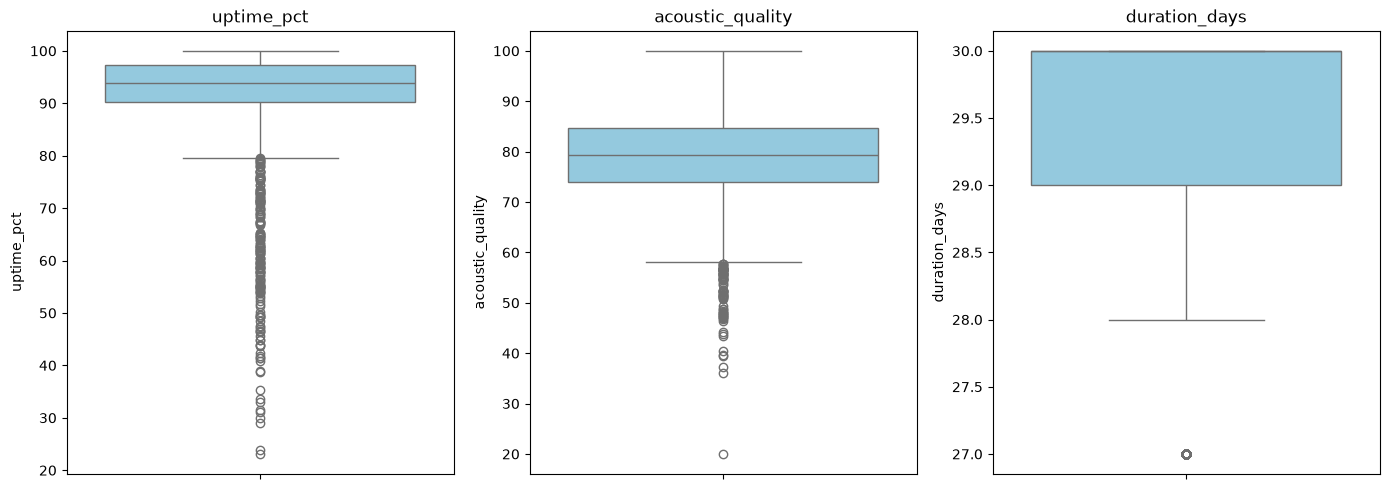

In [29]:
plt.figure(figsize=(14, 5))
for i, col in enumerate(cols_num, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_stats[col], color="skyblue")
    plt.title(col)
plt.tight_layout()
plt.show()

In [30]:
for col in cols_num:
    q1, q3 = df_stats[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    bas, haut = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = ((df_stats[col] < bas) | (df_stats[col] > haut)).sum()
    print(f"{col:20s} min={df_stats[col].min():7.1f} max={df_stats[col].max():7.1f} -> {n} points hors moustaches")

uptime_pct           min=   23.1 max=  100.0 -> 182 points hors moustaches
acoustic_quality     min=   20.0 max=  100.0 -> 82 points hors moustaches
duration_days        min=   27.0 max=   30.0 -> 320 points hors moustaches


### - Justification du traitement des outliers

- Aucune valeur impossible : pourcentages entre 0 et 100, pas de négatif.
- Les `uptime_pct`/`acoustic_quality` bas sont directement expliqués par le type de maintenance :

In [31]:
print(df_stats.groupby('maintenance_type')[['uptime_pct', 'acoustic_quality']].mean().round(1))

                        uptime_pct  acoustic_quality
maintenance_type                                    
corrective maintenance        66.9              66.4
routine inspection            93.7              79.6
sensor replacement            49.4              52.6


→ Les mois de `corrective maintenance` et surtout `sensor replacement` ont un uptime/qualité acoustique
nettement plus faibles que les inspections de routine : ce sont des réalités opérationnelles (l'appareil est
en panne ou hors service pendant la réparation), pas des erreurs de mesure. **On les conserve.**

# 7. Histogrammes et distributions

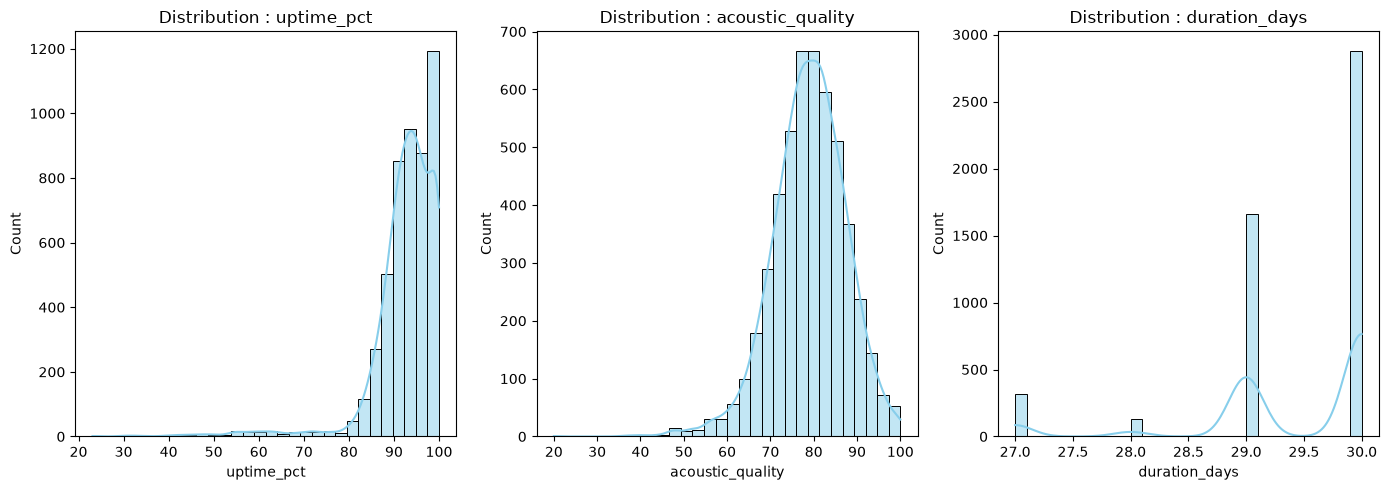

In [32]:
plt.figure(figsize=(14, 5))
for i, col in enumerate(cols_num, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df_stats[col], kde=True, bins=30, color='skyblue')
    plt.title(f"Distribution : {col}")
plt.tight_layout()
plt.show()

In [33]:
print(df_stats[cols_num].skew().round(2))

uptime_pct         -3.38
acoustic_quality   -0.52
duration_days      -1.61
dtype: float64


### - Analyse exploratoire

- `uptime_pct` et `acoustic_quality` sont fortement asymétriques vers la gauche (skew négatif) : la
majorité des opérations sont de bonne qualité, avec une traîne de valeurs basses liée aux interventions
correctives — comportement de type loi de puissance inversée plutôt qu'une loi normale classique.
- `duration_days` est très concentré (presque toutes les opérations durent ~28-31 jours, un cycle mensuel),
donc peu de variance à interpréter ici.

### - Répartition des variables catégorielles

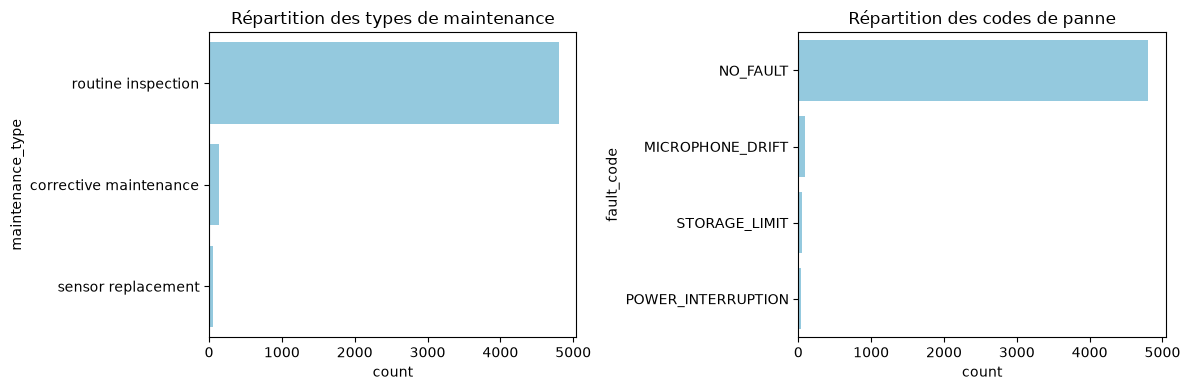

In [34]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.countplot(y='maintenance_type', data=df_stats,
              order=df_stats['maintenance_type'].value_counts().index, color='skyblue')
plt.title("Répartition des types de maintenance")

plt.subplot(1, 2, 2)
sns.countplot(y='fault_code', data=df_stats,
              order=df_stats['fault_code'].value_counts().index, color='skyblue')
plt.title("Répartition des codes de panne")

plt.tight_layout()
plt.show()

# 8. Corrélations

In [35]:
matrice_spearman = df_stats[['uptime_pct', 'acoustic_quality', 'duration_days']].corr(method='spearman')
matrice_pearson = df_stats[['uptime_pct', 'acoustic_quality', 'duration_days']].corr(method='pearson')

display(matrice_spearman.round(2))

,uptime_pct,acoustic_quality,duration_days
uptime_pct,1.00,0.08,-0.00
acoustic_quality,0.08,1.00,-0.02
duration_days,-0.00,-0.02,1.00


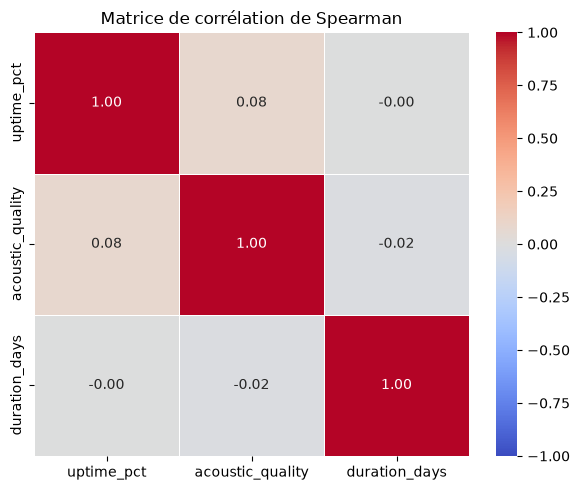

In [36]:
plt.figure(figsize=(6, 5))
sns.heatmap(matrice_spearman, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation de Spearman")
plt.tight_layout()
plt.show()

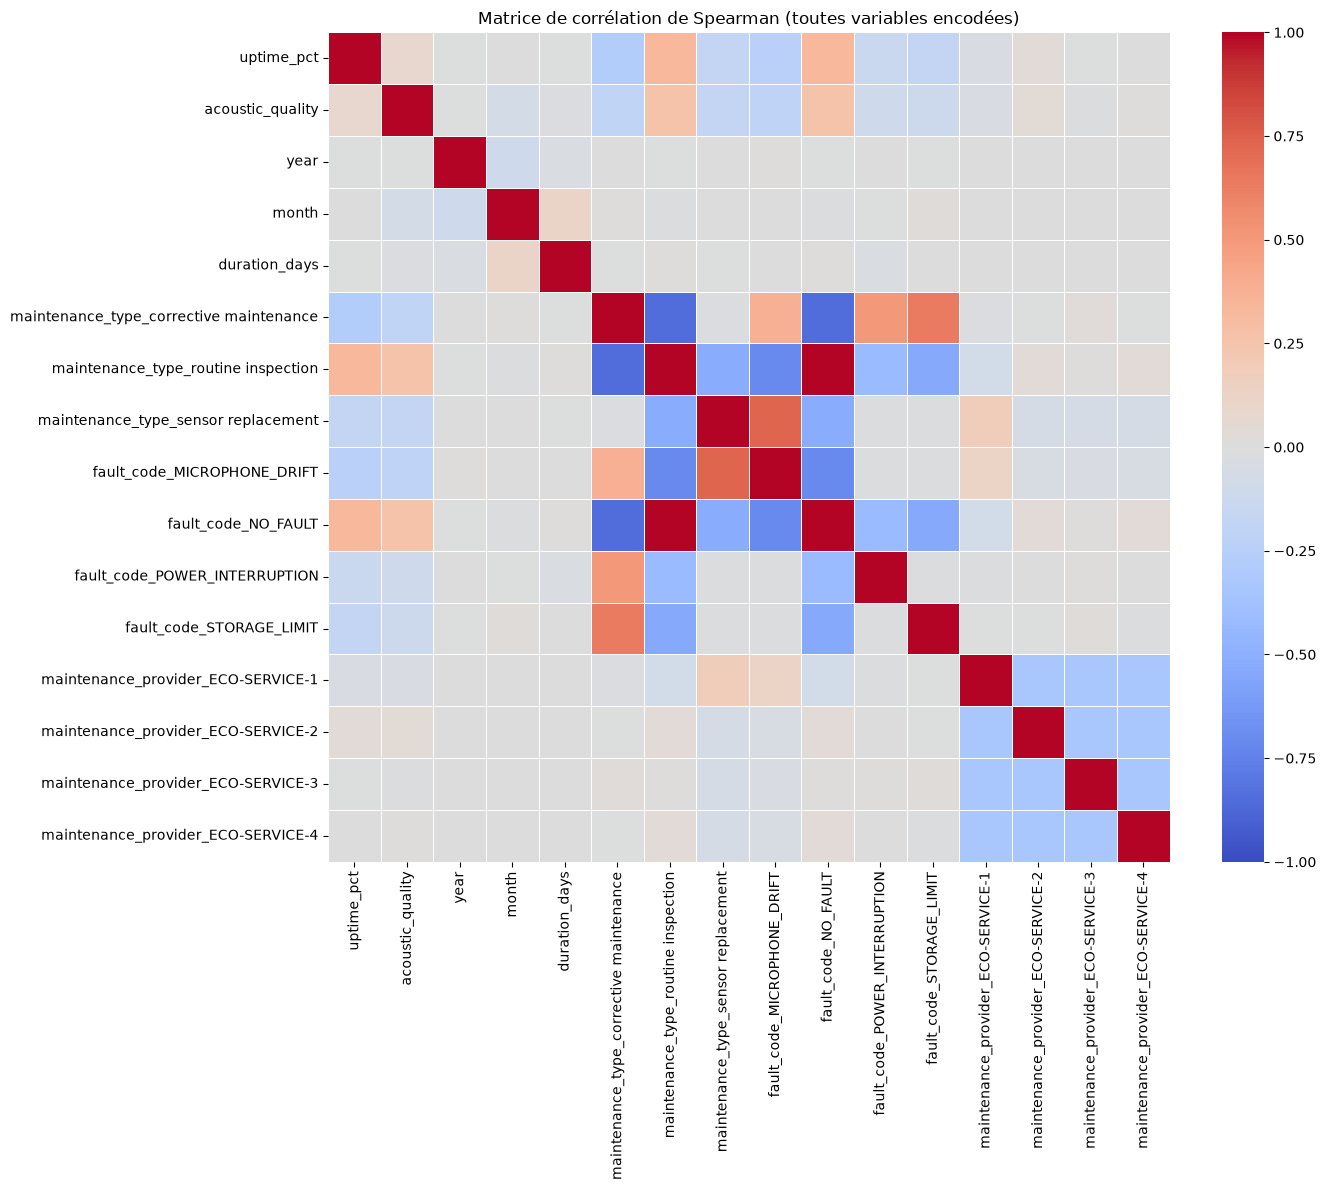

In [37]:
df_num_corr = df_enc.select_dtypes(include='number')
matrice_globale = df_num_corr.corr(method='spearman')

plt.figure(figsize=(14, 12))
sns.heatmap(matrice_globale, annot=False, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matrice de corrélation de Spearman (toutes variables encodées)")
plt.tight_layout()
plt.show()

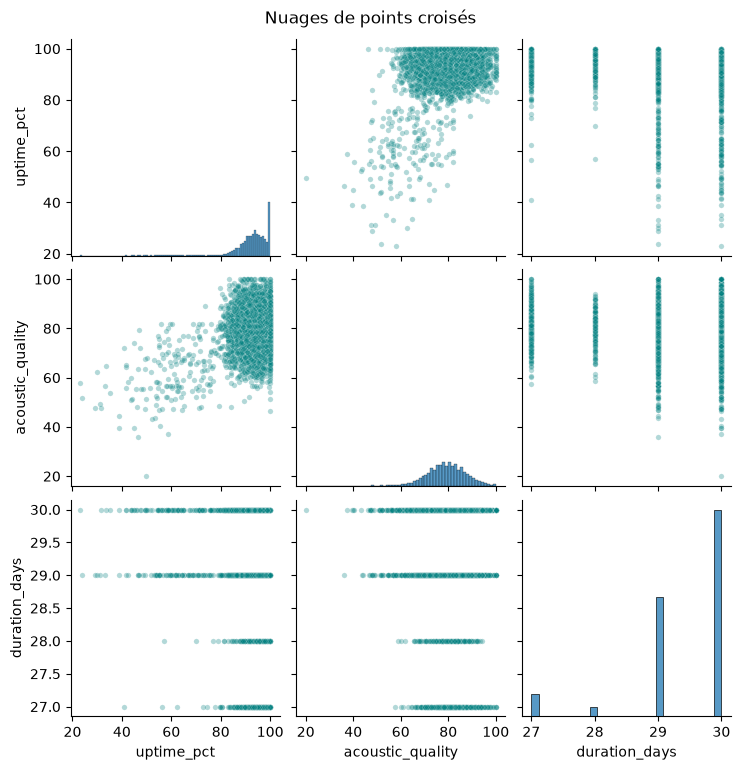

In [38]:
sns.pairplot(df_stats[['uptime_pct', 'acoustic_quality', 'duration_days']],
             kind='scatter', plot_kws={'alpha': 0.3, 'color': 'teal', 's': 15})
plt.suptitle("Nuages de points croisés", y=1.02)
plt.show()

### - Analyse des corrélations

- **`uptime_pct` ↔ `acoustic_quality`** : corrélation positive attendue — un appareil qui tombe hors service
enregistre aussi une moins bonne qualité acoustique pendant la même période.
- **`duration_days`** ne corrèle avec rien : la durée d'un cycle d'opération est quasi fixe (mensuelle), ce
n'est pas un facteur explicatif ici.
- Comme précédemment, **corrélation n'est pas causalité** : le lien réel passe par une variable cachée commune
(le type de maintenance en cours), pas par un effet direct de l'une sur l'autre.

# 9. Export du jeu de données nettoyé

In [39]:
df_enc.to_csv("monitoring_device_operations_clean.csv", index=False)
df_stats.to_csv("monitoring_device_operations_clean_readable.csv", index=False)

print("Dimensions finales (encodé)  :", df_enc.shape)
print("Dimensions finales (lisible) :", df_stats.shape)
print("Valeurs manquantes restantes :", df_enc.isna().sum().sum())

Dimensions finales (encodé)  : (4992, 22)
Dimensions finales (lisible) : (4992, 14)
Valeurs manquantes restantes : 0


# 10. Synthèse du nettoyage

| Problème identifié | Colonnes concernées | Traitement appliqué |
|---|---|---|
| Doublons stricts (2) et doublons d'identifiant | toutes | suppression, on garde la 1ère occurrence |
| Dates au format mixte (`31-May-2025`, `2022/11/30`...) | `operation_end` | conversion `format='mixed'` en `datetime` |
| Séparateur décimal virgule | `uptime_pct` | remplacement `,` → `.` |
| Casse incohérente (5 valeurs pour 3 catégories) | `maintenance_type` | normalisation en minuscules |
| Casse incohérente (3 valeurs pour 1 catégorie) | `record_status` | normalisation en minuscules |
| Manquants "porteurs de sens" (96%) | `fault_code` | remplacés par la modalité `NO_FAULT`, confirmé par le croisement avec `maintenance_type` |
| Manquants isolés (30) | `maintenance_provider` | inférence par site (1 seul prestataire par site) |
| Catégories non encodées | `maintenance_type`, `fault_code`, `maintenance_provider` | One-Hot Encoding strict |
| Valeurs extrêmes (uptime/qualité bas) | numériques | **conservées**, expliquées par le type de maintenance |

**Biais introduits et assumés :**
- l'inférence de `maintenance_provider` par site suppose qu'un site ne change jamais de prestataire sur
toute la période — vérifié sur les données disponibles, mais reste une hypothèse pour les 30 lignes concernées ;
- `record_status` étant constant (`closed`), la colonne est gardée mais n'apportera rien à l'analyse ;
- comme pour `environmental_monthly.csv`, on garde la 1ère occurrence des doublons après avoir vérifié
qu'ils étaient identiques.